# nb04 — Single-donor RNA program characterization

## Scientific question
Which donor and biologically comparable cell populations provide a useful test case,
and which transcriptional programs characterize those populations in each capture?

## Analysis strategy
Inspect the benchmark metadata and count layer without loading the full ATAC matrix.
Select a common donor by an explicit coverage/diversity rule; retain original labels
and audit every broad lineage mapping. Normalize RNA counts independently with the
same log1p(CP10k) convention. Characterize mean expression, detection and specificity
against equally weighted other shared cell types. Rank-enrich one cached human-symbol
Hallmark collection against the same shared gene universe.

This is marker/program characterization in healthy cells, **not condition DE**.
CITE and Multiome are separate captures. Cells must never be cross-matched.

**Run location:** your existing Colab/Drive project, as in nb01. Copy the updated
`src/` directory and these notebooks to Drive before running. Local synthetic tests
do not constitute biological validation. nb01–nb03 are preserved.

In [1]:
from pathlib import Path
import sys
import subprocess

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Same Drive root as nb01. No changes to the original benchmark files.
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'anndata>=0.11,<0.13'])
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics-relationship-modeling')
else:
    BASE_PATH = Path.cwd().resolve()
    if not (BASE_PATH / 'src').is_dir():
        BASE_PATH = BASE_PATH.parent

if not (BASE_PATH / 'src/single_donor_workflow.py').is_file():
    raise FileNotFoundError('Copy the updated src/, configs/ and new notebooks to the project on Drive first.')
sys.path.insert(0, str(BASE_PATH))
import pandas as pd
from IPython.display import display, Image
from configs.paths import CITE_H5AD, MULTIOME_H5AD
from src.single_donor_io import output_dirs

OUTPUT_ROOT = BASE_PATH / 'results/single_donor'
DIRS = output_dirs(OUTPUT_ROOT)
print('Colab:', IN_COLAB, '| Project:', BASE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab: True | Project: /content/drive/MyDrive/multiomics-relationship-modeling


## Parameters and input inspection
Defaults require at least 50 cells per type in each capture, at least three supported
shared types, and no population above 70% of either donor capture. These development
thresholds are explicit, configurable and saved. No donor is hard-coded.

The count layer is used because `.X` has uncertain/incompatible processed scales in
the repository's DATA.md. RNA library size is calculated on **GEX only**, never ADT or
ATAC. Each capture retains its own GEX panel during normalization; panel differences
are a limitation. Existing preprocessing and input files are not overwritten.

In [2]:
from src.single_donor_io import inspect_h5ad

PATHS = {'cite': CITE_H5AD, 'multiome': MULTIOME_H5AD}
MIN_CELLS = 50
MIN_SHARED_TYPES = 3
MAX_DOMINANCE = 0.70
RANDOM_SEED = 42
PERMUTATIONS = 1000
MIN_DETECTION = 0.01
COMPUTE_MEDIANS = False  # optional blockwise sparse->dense calculation
MAPPING_OVERRIDE = None  # path to a reviewed copy of celltype_mapping.csv

for dataset, path in PATHS.items():
    if not path.is_file():
        raise FileNotFoundError(f'{dataset}: missing {path}; use the same data/benchmark location as nb01.')
    obs, var, audit = inspect_h5ad(path)
    print(dataset, audit)
    display(obs.groupby(['DonorID', 'Site'], observed=True).size().rename('n_cells').reset_index())
    print('Original labels:', sorted(obs.cell_type.unique()))
del obs, var

cite {'path': '/content/drive/MyDrive/multiomics-relationship-modeling/data/benchmark/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad', 'file_bytes': 624797386, 'file_mtime_ns': 1782768387000000000, 'shape': [90261, 14087], 'feature_types': {'GEX': 13953, 'ADT': 134}, 'repeated_feature_names': [{'name': 'CD52', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD58', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD2', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD101', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD48', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD244', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD28', 'feature_types': ['GEX', 'ADT']}, {'name': 'CX3CR1', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD47', 'feature_types': ['GEX', 'ADT']}, {'name': 'TIGIT', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD86', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD38', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD14', 'feature_types': ['GEX', 'ADT']}, {'name': 'CD83', 'feature

,DonorID,Site,n_cells
0,10886,site1,4978
1,11466,site3,11473
2,12710,site2,5584
3,13272,site4,7365
4,15078,site1,5227
5,15078,site2,10465
6,15078,site3,9521
7,15078,site4,5456
8,16710,site2,9122
9,18303,site1,6106


Original labels: ['B1 B IGKC+', 'B1 B IGKC-', 'CD14+ Mono', 'CD16+ Mono', 'CD4+ T CD314+ CD45RA+', 'CD4+ T activated', 'CD4+ T activated integrinB7+', 'CD4+ T naive', 'CD8+ T CD49f+', 'CD8+ T CD57+ CD45RA+', 'CD8+ T CD57+ CD45RO+', 'CD8+ T CD69+ CD45RA+', 'CD8+ T CD69+ CD45RO+', 'CD8+ T TIGIT+ CD45RA+', 'CD8+ T TIGIT+ CD45RO+', 'CD8+ T naive', 'CD8+ T naive CD127+ CD26- CD101-', 'Erythroblast', 'G/M prog', 'HSC', 'ILC', 'ILC1', 'Lymph prog', 'MAIT', 'MK/E prog', 'NK', 'NK CD158e1+', 'Naive CD20+ B IGKC+', 'Naive CD20+ B IGKC-', 'Normoblast', 'Plasma cell IGKC+', 'Plasma cell IGKC-', 'Plasmablast IGKC+', 'Plasmablast IGKC-', 'Proerythroblast', 'Reticulocyte', 'T prog cycling', 'T reg', 'Transitional B', 'cDC1', 'cDC2', 'dnT', 'gdT CD158b+', 'gdT TCRVD2+', 'pDC']
multiome {'path': '/content/drive/MyDrive/multiomics-relationship-modeling/data/benchmark/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad', 'file_bytes': 3116868580, 'file_mtime_ns': 1782768739000000000, 'shape':

,DonorID,Site,n_cells
0,10886,site1,6740
1,11466,site3,1771
2,12710,site2,6111
3,13272,site4,4325
4,15078,site1,6224
5,15078,site2,4220
6,15078,site4,8023
7,16710,site2,4895
8,18303,site1,4279
9,18303,site3,4325


Original labels: ['B1 B', 'CD14+ Mono', 'CD16+ Mono', 'CD4+ T activated', 'CD4+ T naive', 'CD8+ T', 'CD8+ T naive', 'Erythroblast', 'G/M prog', 'HSC', 'ID2-hi myeloid prog', 'ILC', 'Lymph prog', 'MK/E prog', 'NK', 'Naive CD20+ B', 'Normoblast', 'Plasma cell', 'Proerythroblast', 'Transitional B', 'cDC2', 'pDC']


## Donor selection and explicit cell-type harmonization
Candidates are ranked by eligible shared-type coverage, sum of minimum per-type cell
counts across captures, lower maximum dominance, then donor ID. Dominance includes
unresolved cells. The full donor ranking records the criteria and selection.

Mappings are explicit code rules, not fuzzy label matching. CD4/CD8 subtypes, B-cell
subtypes and erythroid stages are pooled as documented. HSC, lymphoid, G/M and MK/E
progenitors remain separate; pDC and cDC populations remain separate. Labels such as
T reg, MAIT, gamma-delta T, ILC1 and plasmablasts are not silently assigned to broader
comparators. Exact otherwise-unmapped labels can be retained if present in both.

**Review the mapping and subtype composition before interpreting results.** To revise
it, copy `celltype_mapping.csv`, edit the harmonized labels/confidence/reasons, set
`MAPPING_OVERRIDE` above, and rerun. Do not edit a saved result in place and continue
with stale downstream outputs. Unresolved or undersized populations remain in audits
but are excluded from the shared RNA reference.

Automatically selected donor: 15078


,DonorID,n_cite,n_original_types_cite,n_harmonized_types_cite,dominance_cite,effective_types_cite,n_unresolved_cite,sites_cite,n_multiome,n_original_types_multiome,...,n_unresolved_multiome,sites_multiome,n_shared_types,n_supported_shared_types,joint_cells,max_dominance,shared_sites,eligible,selected,selection_rule
0,15078,30669,40,15,0.236199,9.674396,981,site1;site2;site3;site4,18467,21,...,67,site1;site2;site4,15,15,17914,0.236199,site1;site2;site4,True,True,>=3 shared types with >=50 cells per capture; ...
1,12710,5584,30,14,0.231734,9.270622,123,site2,6111,17,...,0,site2,13,11,4682,0.399607,site2,True,False,>=3 shared types with >=50 cells per capture; ...
2,13272,7365,36,14,0.214121,10.304015,711,site4,4325,18,...,0,site4,12,10,4275,0.355376,site4,True,False,>=3 shared types with >=50 cells per capture; ...
3,10886,4978,41,15,0.274608,10.168846,390,site1,6740,21,...,41,site1,15,10,4025,0.296439,site1,True,False,>=3 shared types with >=50 cells per capture; ...
4,18303,6106,36,14,0.249263,7.615789,290,site1,8604,21,...,0,site1;site3,14,9,5424,0.249263,site1,True,False,>=3 shared types with >=50 cells per capture; ...
5,19593,3929,33,14,0.374141,7.679146,115,site4,9876,19,...,0,site4,14,9,3676,0.414034,site4,True,False,>=3 shared types with >=50 cells per capture; ...
6,16710,9122,34,15,0.280750,6.981607,160,site2,4895,16,...,0,site2,12,8,4734,0.350562,site2,True,False,>=3 shared types with >=50 cells per capture; ...
7,11466,11473,34,15,0.527848,6.333940,210,site3,1771,18,...,0,site3,13,7,1632,0.527848,site3,True,False,>=3 shared types with >=50 cells per capture; ...
8,28045,11035,36,14,0.265247,10.194599,244,site3,1679,18,...,0,site3,13,7,1495,0.290649,site3,True,False,>=3 shared types with >=50 cells per capture; ...


,CITE label,Multiome label,Harmonized label,Mapping confidence,Reason
0,B1 B IGKC+; B1 B IGKC-; Naive CD20+ B IGKC+; N...,B1 B; Naive CD20+ B; Transitional B,B cells,moderate: broad lineage only,Broad lineage; subtype composition may differ;...
1,CD14+ Mono,CD14+ Mono,CD14 monocytes,high,Explicit lineage rule; inspect original subtyp...
2,CD16+ Mono,CD16+ Mono,CD16 monocytes,high,Explicit lineage rule; inspect original subtyp...
3,CD4+ T CD314+ CD45RA+; CD4+ T activated; CD4+ ...,CD4+ T activated; CD4+ T naive,CD4 T cells,moderate: broad lineage only,Broad lineage; subtype composition may differ
4,CD8+ T CD49f+; CD8+ T CD57+ CD45RA+; CD8+ T CD...,CD8+ T; CD8+ T naive,CD8 T cells,moderate: broad lineage only,Broad lineage; subtype composition may differ
5,Erythroblast; Normoblast; Proerythroblast; Ret...,Erythroblast; Normoblast; Proerythroblast,Erythroid populations,moderate: broad lineage only,Explicit lineage rule; inspect original subtyp...
6,G/M prog,G/M prog,G/M progenitors,high,Explicit lineage rule; inspect original subtyp...
7,HSC,HSC,HSC,high,Explicit lineage rule; inspect original subtyp...
8,ILC,ILC,ILC,high,Explicit lineage rule; inspect original subtyp...
9,Lymph prog,Lymph prog,Lymphoid progenitors,high,Explicit lineage rule; inspect original subtyp...


,dataset,original_label,harmonized_label,mapping_confidence,mapping_type,exact_label_in_both,reason
0,cite,B1 B IGKC+,B cells,moderate: broad lineage only,hierarchical,False,Broad lineage; subtype composition may differ
1,cite,B1 B IGKC-,B cells,moderate: broad lineage only,hierarchical,False,Broad lineage; subtype composition may differ
2,cite,CD14+ Mono,CD14 monocytes,high,hierarchical,True,Explicit lineage rule; inspect original subtyp...
3,cite,CD16+ Mono,CD16 monocytes,high,hierarchical,True,Explicit lineage rule; inspect original subtyp...
4,cite,CD4+ T activated,CD4 T cells,moderate: broad lineage only,hierarchical,True,Broad lineage; subtype composition may differ
...,...,...,...,...,...,...,...
56,multiome,Plasma cell,Plasma cells,moderate: broad lineage only,hierarchical,False,Plasma lineage; light-chain subsets pooled
57,multiome,Proerythroblast,Erythroid populations,moderate: broad lineage only,hierarchical,True,Explicit lineage rule; inspect original subtyp...
58,multiome,Transitional B,B cells,moderate: broad lineage only,hierarchical,True,Explicit lineage rule; inspect original subtyp...
59,multiome,cDC2,cDC2,high,hierarchical,True,Explicit lineage rule; inspect original subtyp...


,cite,multiome,included
cell_type_harmonized,,,
CD14 monocytes,7244,3243,True
CD4 T cells,5619,3099,True
Erythroid populations,5067,2851,True
B cells,3449,2798,True
CD8 T cells,2545,1653,True
NK cells,1647,1984,True
CD16 monocytes,865,526,True
pDC,696,338,True
cDC2,546,181,True


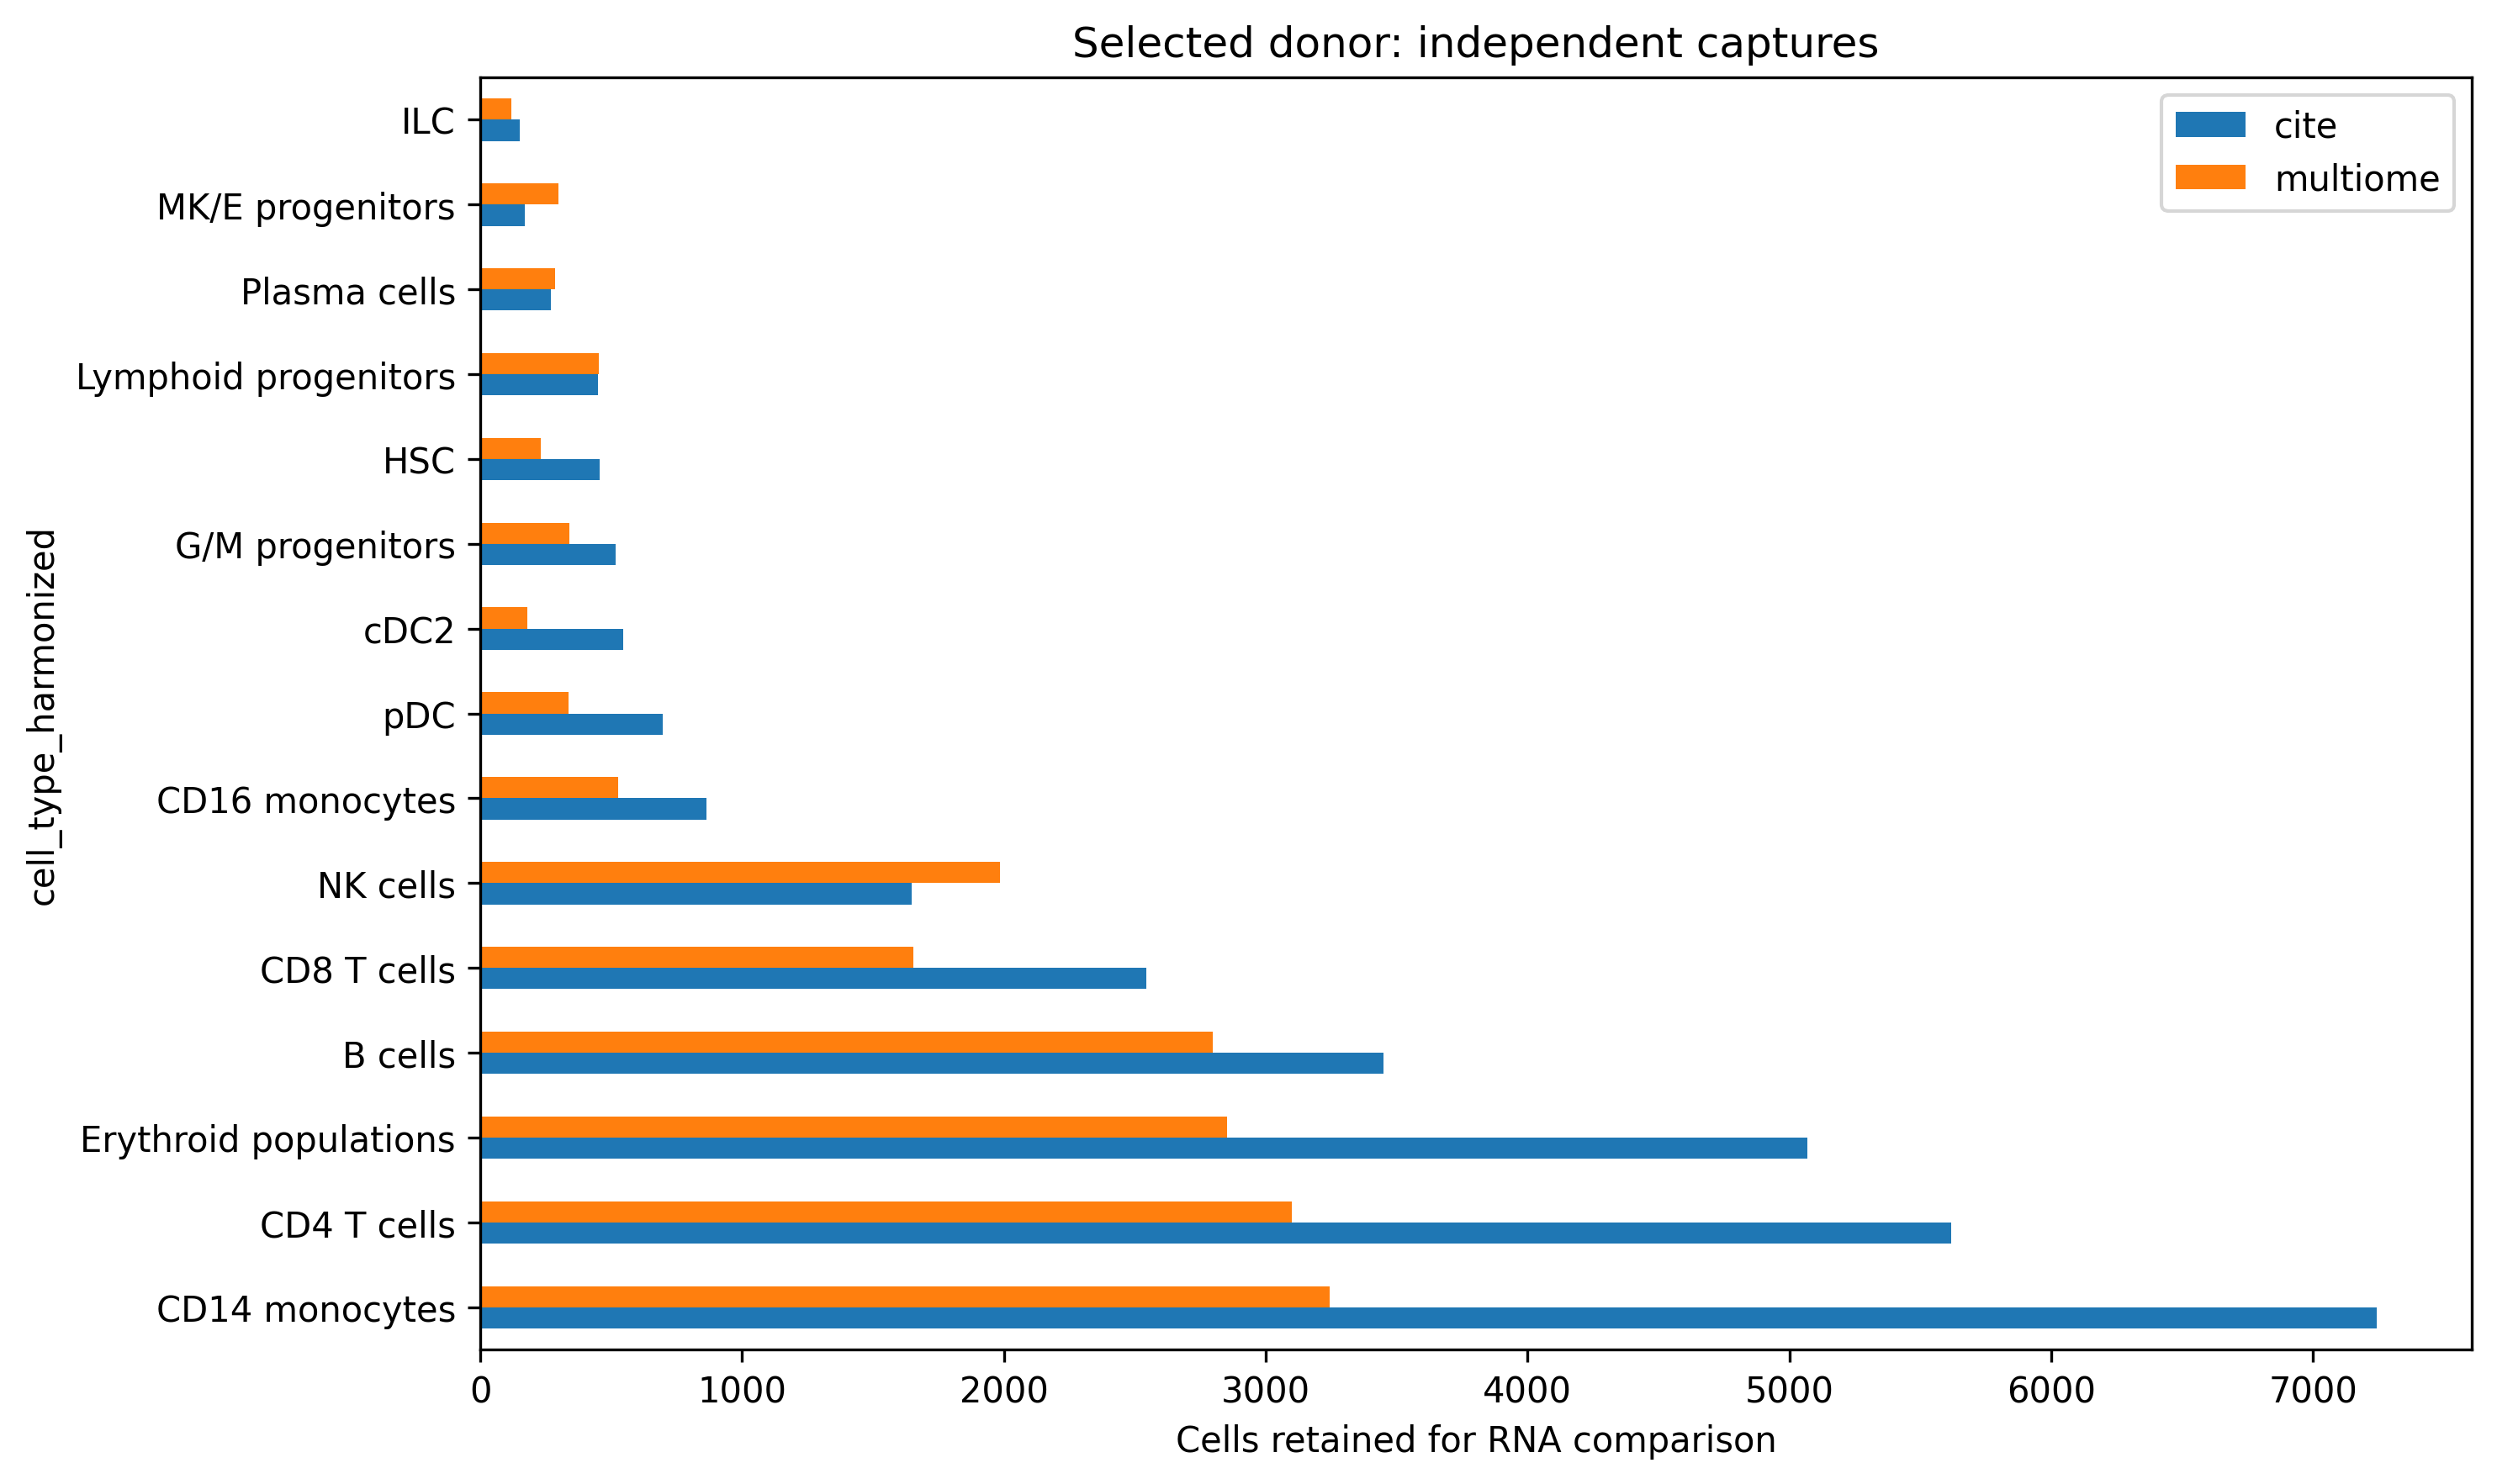

In [3]:
from src.single_donor_workflow import prepare_donor

donor, donor_ranking, cell_counts, rna_data = prepare_donor(
    PATHS, OUTPUT_ROOT, min_cells=MIN_CELLS, min_shared=MIN_SHARED_TYPES,
    max_dominance=MAX_DOMINANCE, mapping_override=MAPPING_OVERRIDE)
print('Automatically selected donor:', donor)
display(donor_ranking)
display(pd.read_csv(DIRS['donor_selection'] / 'celltype_mapping_paired.csv'))
display(pd.read_csv(DIRS['donor_selection'] / 'selected_donor_mapping.csv'))
display(cell_counts)
display(Image(filename=str(DIRS['donor_selection'] / 'figures/cell_counts.png')))

## Independent RNA profiles and ranked enrichment
Mean expression is the mean of log1p(CP10k), not log of an aggregated count total.
Specificity is target-type mean minus the equally weighted mean of other retained
types. All types use the same reference populations in both datasets.

Mitochondrial, ribosomal and selected housekeeping genes are **flagged**, retained in
complete rankings, and excluded only from the compact marker figure where indicated.
Technical spike-ins are excluded from enrichment. Shared genes must be detected in
at least 1% of cells in at least one retained type in **each** capture; this creates
one fixed, symmetric universe, not separate cell-type-specific gene filters.

The default collection is Enrichr's `MSigDB_Hallmark_2020` human-symbol library (50
sets). The first run downloads it explicitly; subsequent runs reuse the exact GMT.
Its SHA256 and bytes are saved. A locally supplied human-symbol Hallmark, Reactome or
GO-BP GMT may be substituted, but both datasets must use the same file. No fabricated
gene sets or automatic database substitution are used on network failure.

The dependency-light GSEA-style implementation uses a weighted running-sum statistic
(p=1), same-sign gene-set permutation nulls, NES, and plus-one nominal p-values.
`q_value` is **Benjamini–Hochberg within dataset × cell type**, not Broad's pooled GSEA
FDR. An additional pooled BH column is saved in `all_enrichment.csv`. Null gene sets
ignore gene correlations, so significance is exploratory. No individual-level
replication is implied. Stable gene-symbol ordering breaks rank ties; tie fractions
and gene-set coverage are reported. Sets need 15–500 overlapping genes and fewer than
the full ranking. Negative enrichment means lower **relative specificity**, not
absence/inactivity of a biological pathway.

Method reference: [GSEA User Guide](https://docs.gsea-msigdb.org/GSEA/GSEA_User_Guide/).

Cached collection SHA256: 4275592957a1587652092bb398cf77216fde5b8daa2aedaa0e016f7d10bbdb81
Shared eligible genes: 12000


,pathway,n_original,n_overlap,included
0,TNF-alpha Signaling via NF-kB,200,160,True
1,Hypoxia,200,129,True
2,Cholesterol Homeostasis,74,59,True
3,Mitotic Spindle,199,188,True
4,Wnt-beta Catenin Signaling,42,28,True
5,TGF-beta Signaling,54,46,True
6,IL-6/JAK/STAT3 Signaling,87,63,True
7,DNA Repair,150,141,True
8,G2-M Checkpoint,200,189,True
9,Apoptosis,161,125,True


cite


,gene,mitochondrial,ribosomal,housekeeping_flag,technical_flag,enrichment_eligible,cell_type,n_cells,mean_expression,fraction_expressing,specificity,mean_rank,specificity_rank,comparison_eligible
76993,HBB,False,False,False,False,True,Erythroid populations,5067,8.398156,1.000000,6.529959,1.0,1.0,True
79648,HBA2,False,False,False,False,True,Erythroid populations,5067,6.452650,0.994869,5.367053,2.0,2.0,True
79649,HBA1,False,False,False,False,True,Erythroid populations,5067,6.040656,0.998421,5.247844,3.0,3.0,True
14833,S100A9,False,False,False,False,True,CD14 monocytes,7244,5.628601,0.999172,4.829160,1.0,1.0,True
76994,HBD,False,False,False,False,True,Erythroid populations,5067,4.984413,0.999408,4.654261,4.0,4.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101808,NPM1,False,False,False,False,True,HSC,455,2.823096,0.989011,1.378271,98.0,4.0,True
147627,LDHB,False,False,False,False,True,MK/E progenitors,169,2.134284,0.970414,1.361944,123.0,4.0,True
50835,TRAC,False,False,False,False,True,CD4 T cells,5619,1.464170,0.709201,1.305254,168.0,5.0,True
141718,EEF1B2,False,False,False,False,True,MK/E progenitors,169,3.567237,0.994083,1.295694,67.0,5.0,True


,pathway,ES,NES,p_value,direction,leading_edge,n_genes,n_original_genes,coverage,permutations,n_null_same_sign,tied_fraction,q_value,cell_type,n_cells,dataset,donor
0,Adipogenesis,-0.547825,-1.583890,0.001718,negative,IDH3A;ELOVL6;DGAT1;PREB;ACOX1;NABP1;LPCAT3;SDH...,166,200,0.830000,1000,581,0.0,0.009452,B cells,3449,cite,15078
9,Coagulation,-0.750453,-1.866129,0.001610,negative,LAMP2;WDR1;ARF4;DUSP6;GNB2;CAPN2;GSN;MSRB2;PEC...,53,138,0.384058,1000,620,0.0,0.009452,B cells,3449,cite,15078
10,Complement,-0.694481,-1.980496,0.001736,negative,LRP1;CDA;USP15;PLSCR1;GNG2;CA2;SH2B3;GZMK;IRF7...,135,200,0.675000,1000,575,0.0,0.009452,B cells,3449,cite,15078
12,E2F Targets,-0.653321,-1.955911,0.001661,negative,MMS22L;ASF1B;EIF2S1;MXD3;RAD51AP1;CDC20;ASF1A;...,195,200,0.975000,1000,601,0.0,0.009452,B cells,3449,cite,15078
13,Epithelial Mesenchymal Transition,-0.644265,-1.665418,0.001672,negative,RHOB;ITGB1;CALU;LRP1;CXCL8;TGFBR3;DST;DAB2;TPM...,74,200,0.370000,1000,597,0.0,0.009452,B cells,3449,cite,15078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
719,Oxidative Phosphorylation,0.644417,1.447225,0.002016,positive,ATP5F1E;NDUFV2;IDH3A;ATP6V0B;ATP6V0E1;COX7A2;N...,196,200,0.980000,1000,991,0.0,0.049395,pDC,696,cite,15078
729,Unfolded Protein Response,0.743859,1.626216,0.001044,positive,SPCS1;HSP90B1;HERPUD1;DDIT4;TSPYL2;SERP1;SPCS3...,102,113,0.902655,1000,957,0.0,0.049395,pDC,696,cite,15078
715,Myc Targets V1,0.589246,1.323323,0.014113,positive,PHB;RPLP0;RPL6;CANX;PPIA;RPS5;EEF1B2;RPL18;RAC...,196,200,0.980000,1000,991,0.0,0.172883,pDC,696,cite,15078
722,Protein Secretion,0.657322,1.431842,0.010661,positive,CTSC;GNAS;TMED10;COPE;STX7;ARF1;TMED2;LMAN1;M6...,89,96,0.927083,1000,937,0.0,0.172883,pDC,696,cite,15078


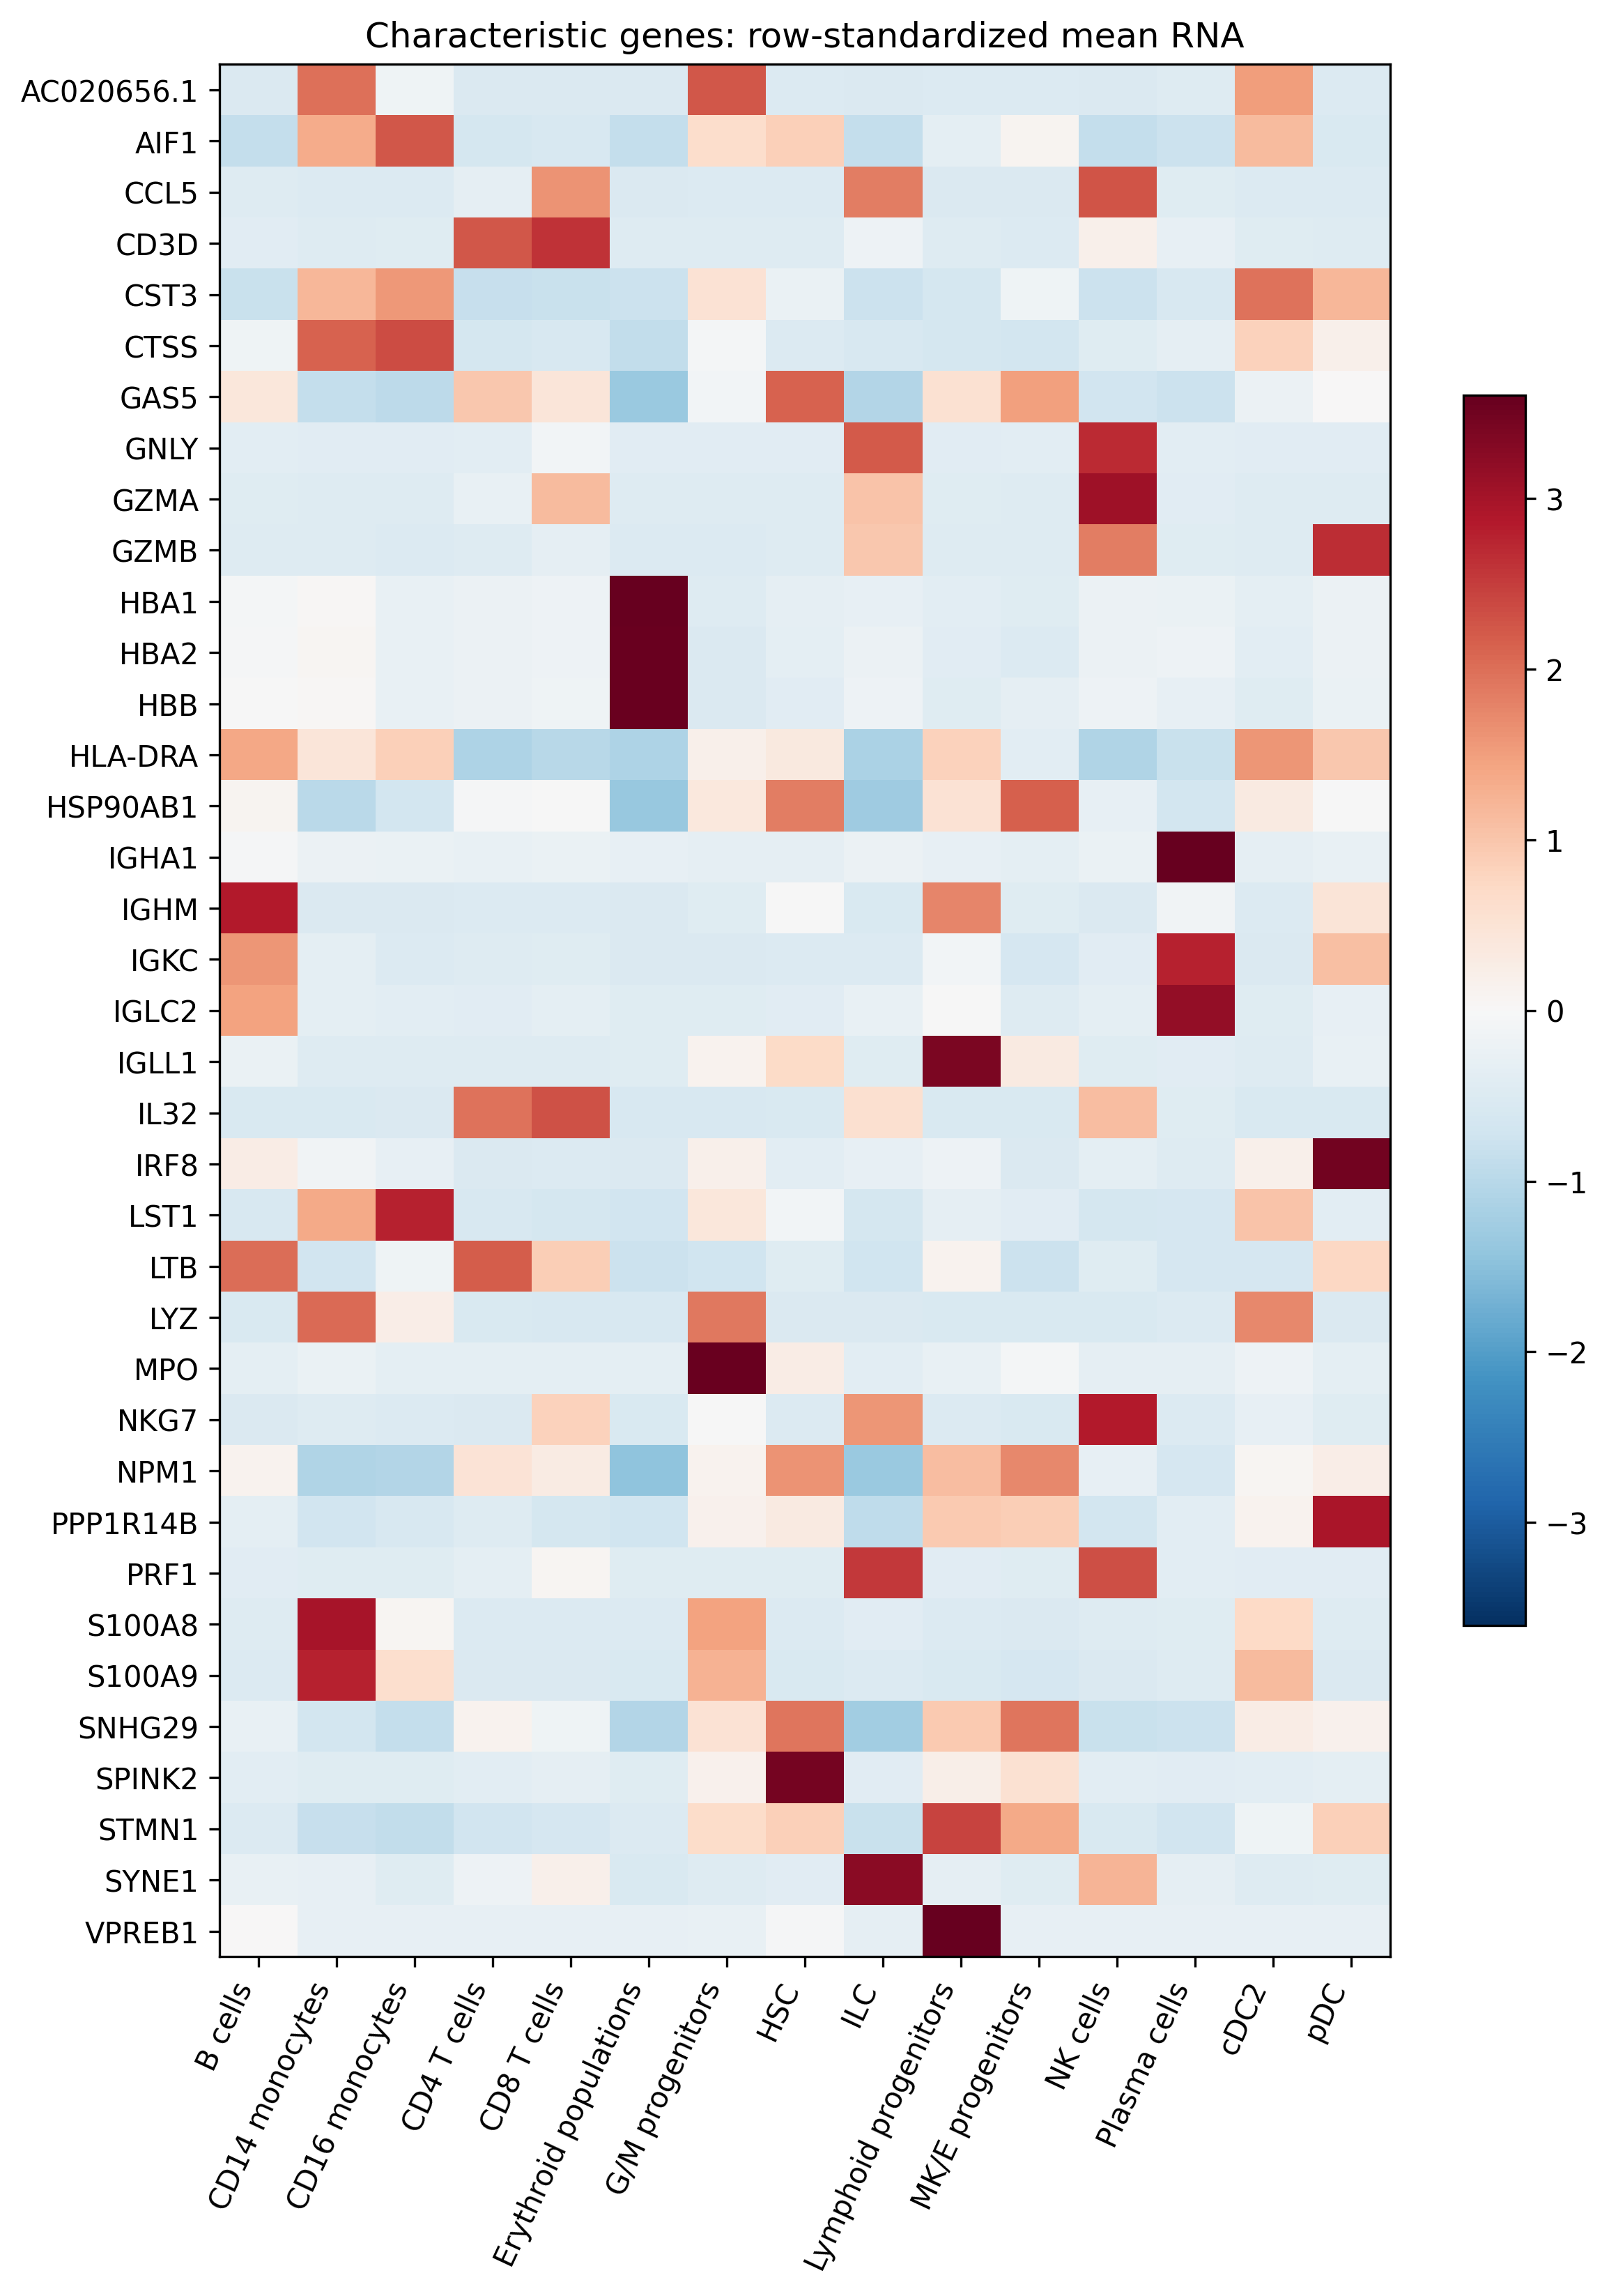

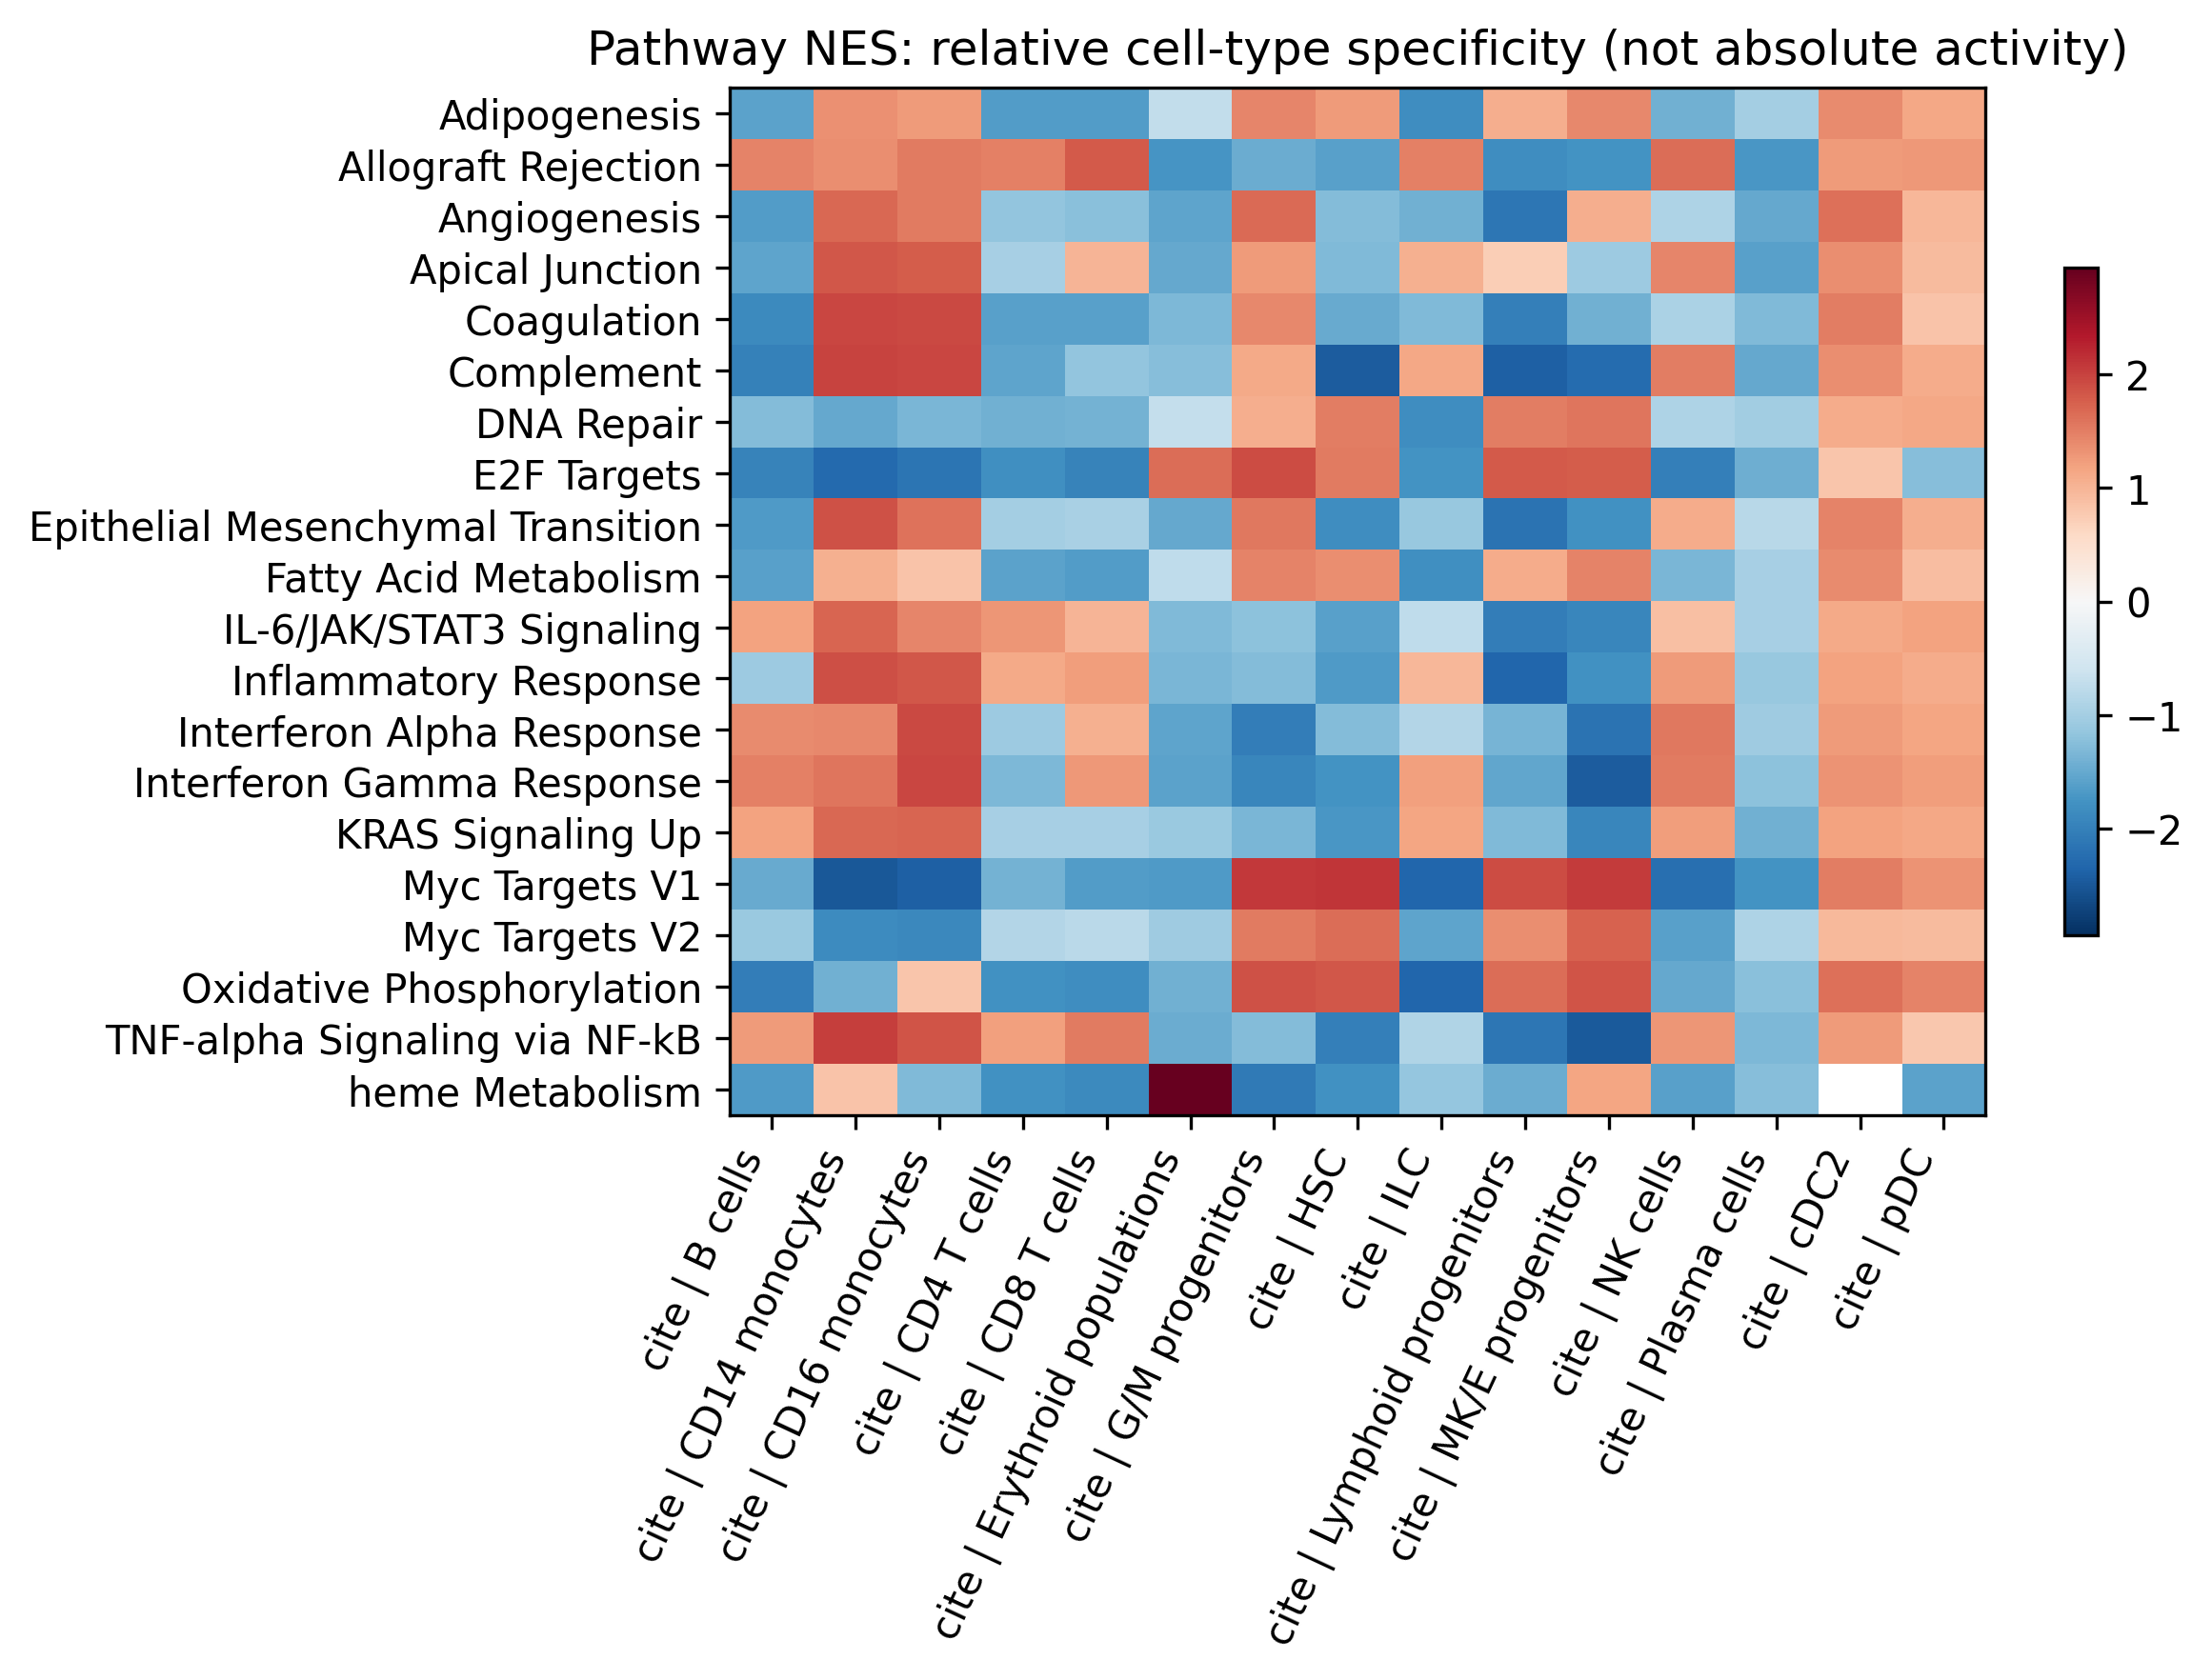

multiome


,gene,mitochondrial,ribosomal,housekeeping_flag,technical_flag,enrichment_eligible,cell_type,n_cells,mean_expression,fraction_expressing,specificity,mean_rank,specificity_rank,comparison_eligible
77852,SLC4A1,False,False,False,False,True,Erythroid populations,2851,3.390272,0.907752,3.286481,7.0,1.0,True
76827,HBA2,False,False,False,False,True,Erythroid populations,2851,4.700780,0.962820,3.273547,3.0,2.0,True
72780,SLC25A37,False,False,False,False,True,Erythroid populations,2851,3.545761,0.952297,3.257083,6.0,3.0,True
199229,TCF4,False,False,False,False,True,pDC,338,3.968517,0.982249,3.198821,2.0,1.0,True
76828,HBA1,False,False,False,False,True,Erythroid populations,2851,4.300517,0.958260,3.193915,4.0,4.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44163,CAMK4,False,False,False,False,True,CD4 T cells,3099,1.750516,0.654727,1.522499,76.0,5.0,True
83524,FNDC3B,False,False,False,False,True,G/M progenitors,341,2.489173,0.894428,1.505651,12.0,5.0,True
64475,SKAP1,False,False,False,False,True,CD8 T cells,1653,2.293785,0.761645,1.477653,15.0,3.0,True
58485,THEMIS,False,False,False,False,True,CD8 T cells,1653,1.715951,0.607985,1.466755,57.0,4.0,True


,pathway,ES,NES,p_value,direction,leading_edge,n_genes,n_original_genes,coverage,permutations,n_null_same_sign,tied_fraction,q_value,cell_type,n_cells,dataset,donor
9,Coagulation,-0.615829,-1.558235,0.001196,negative,ADAM9;SERPINA1;WDR1;LRP1;CFD;TIMP1;A2M;PREP;DU...,53,138,0.384058,1000,835,0.0,0.007327,B cells,2798,multiome,15078
10,Complement,-0.534479,-1.521487,0.001127,negative,PIM1;ADAM9;GATA3;GZMK;SERPINA1;ITGAM;CASP1;CAS...,135,200,0.675000,1000,886,0.0,0.007327,B cells,2798,multiome,15078
13,Epithelial Mesenchymal Transition,-0.617112,-1.627132,0.001176,negative,GLIPR1;IL15;RHOB;ITGAV;MCM7;LRP1;CD59;TIMP1;NO...,74,200,0.370000,1000,849,0.0,0.007327,B cells,2798,multiome,15078
17,G2-M Checkpoint,-0.511542,-1.487003,0.001095,negative,KIF22;DDX39A;CDKN1B;CCNT1;ATRX;ARID4A;CHEK1;NU...,189,200,0.945000,1000,912,0.0,0.007327,B cells,2798,multiome,15078
29,Myc Targets V1,-0.609115,-1.775634,0.001085,negative,CCT3;PSMD8;KPNA2;PSMC6;CYC1;EIF3D;SNRPD2;VDAC3...,196,200,0.980000,1000,921,0.0,0.007327,B cells,2798,multiome,15078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,IL-2/STAT5 Signaling,0.625159,1.484995,0.001011,positive,IRF8;RABGAP1L;IRF4;MYO1E;MAPKAPK2;SCN9A;NRP1;A...,161,199,0.809045,1000,988,0.0,0.049545,pDC,338,multiome,15078
729,Unfolded Protein Response,0.655718,1.515507,0.003128,positive,ERN1;HSP90B1;SLC7A5;HERPUD1;YWHAZ;EIF4A3;TTC37...,102,113,0.902655,1000,958,0.0,0.076642,pDC,338,multiome,15078
687,Allograft Rejection,0.549063,1.292391,0.039634,positive,IRF8;CD74;HDAC9;IRF4;IRF7;HLA-DRA;LYN;HLA-DQA1...,158,200,0.790000,1000,983,0.0,0.194207,pDC,338,multiome,15078
689,Angiogenesis,0.827046,1.599928,0.017333,positive,APP;NRP1;TNFRSF21;PTK2,15,36,0.416667,1000,749,0.0,0.194207,pDC,338,multiome,15078


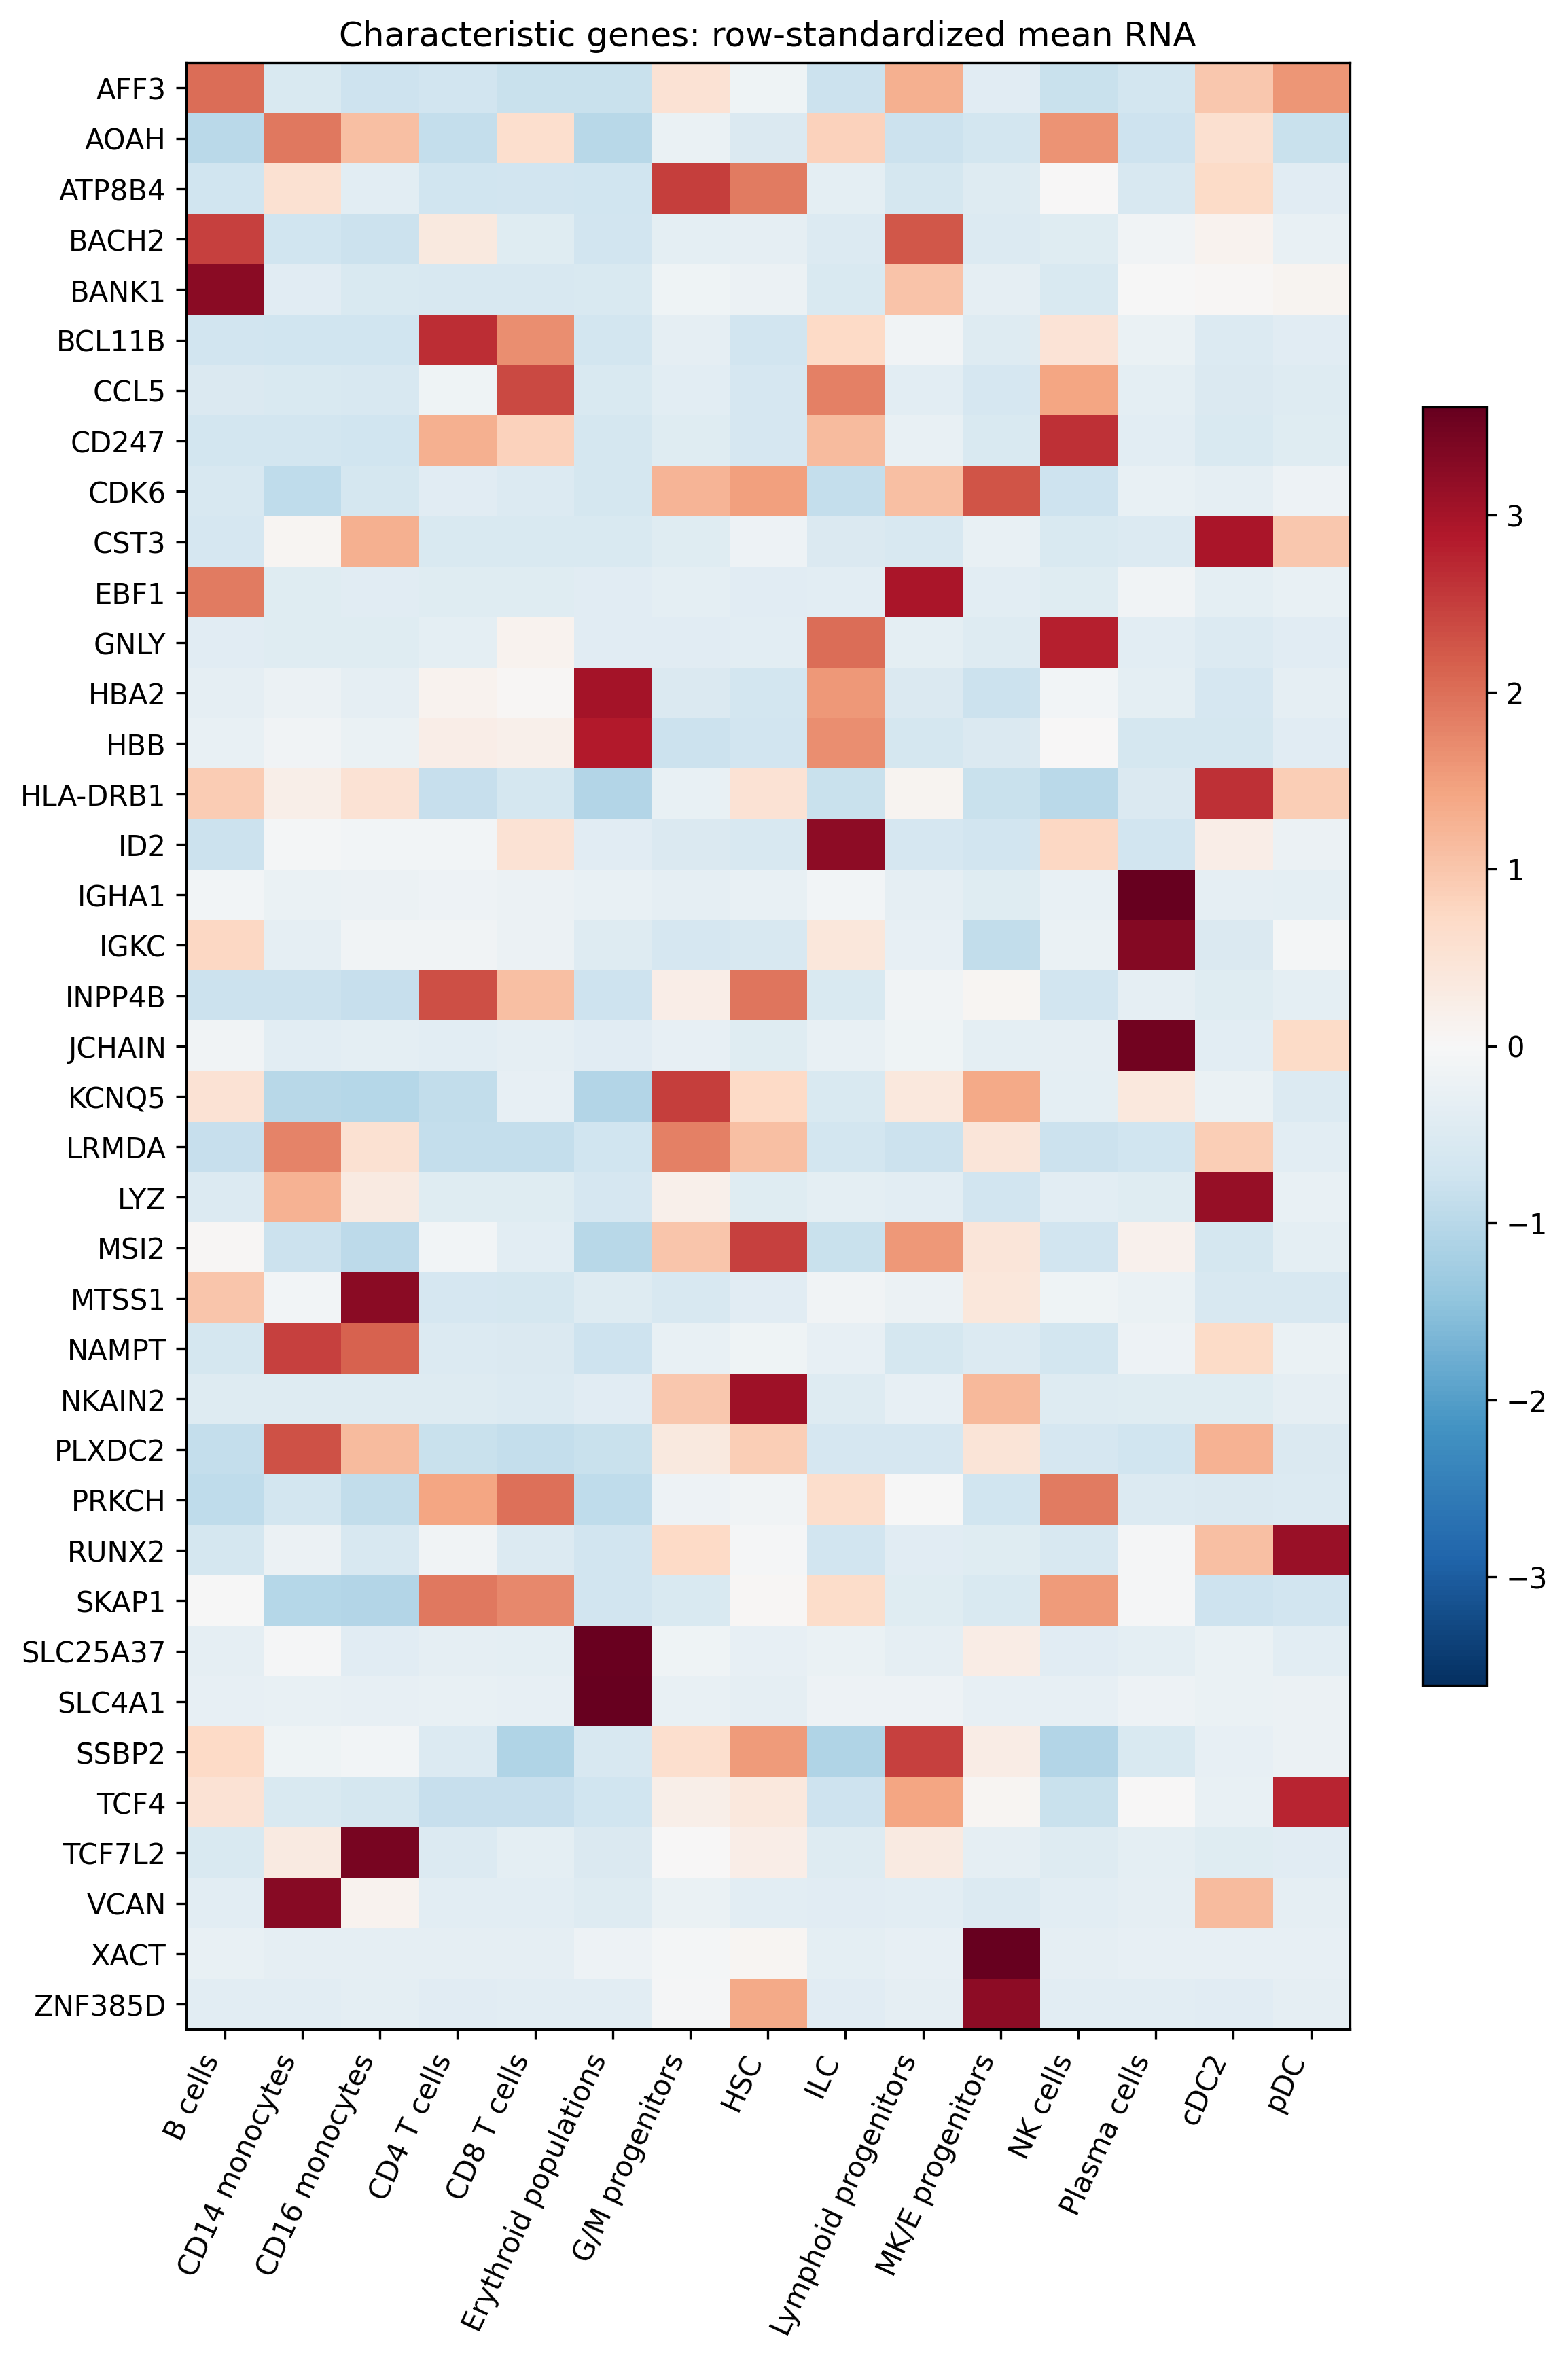

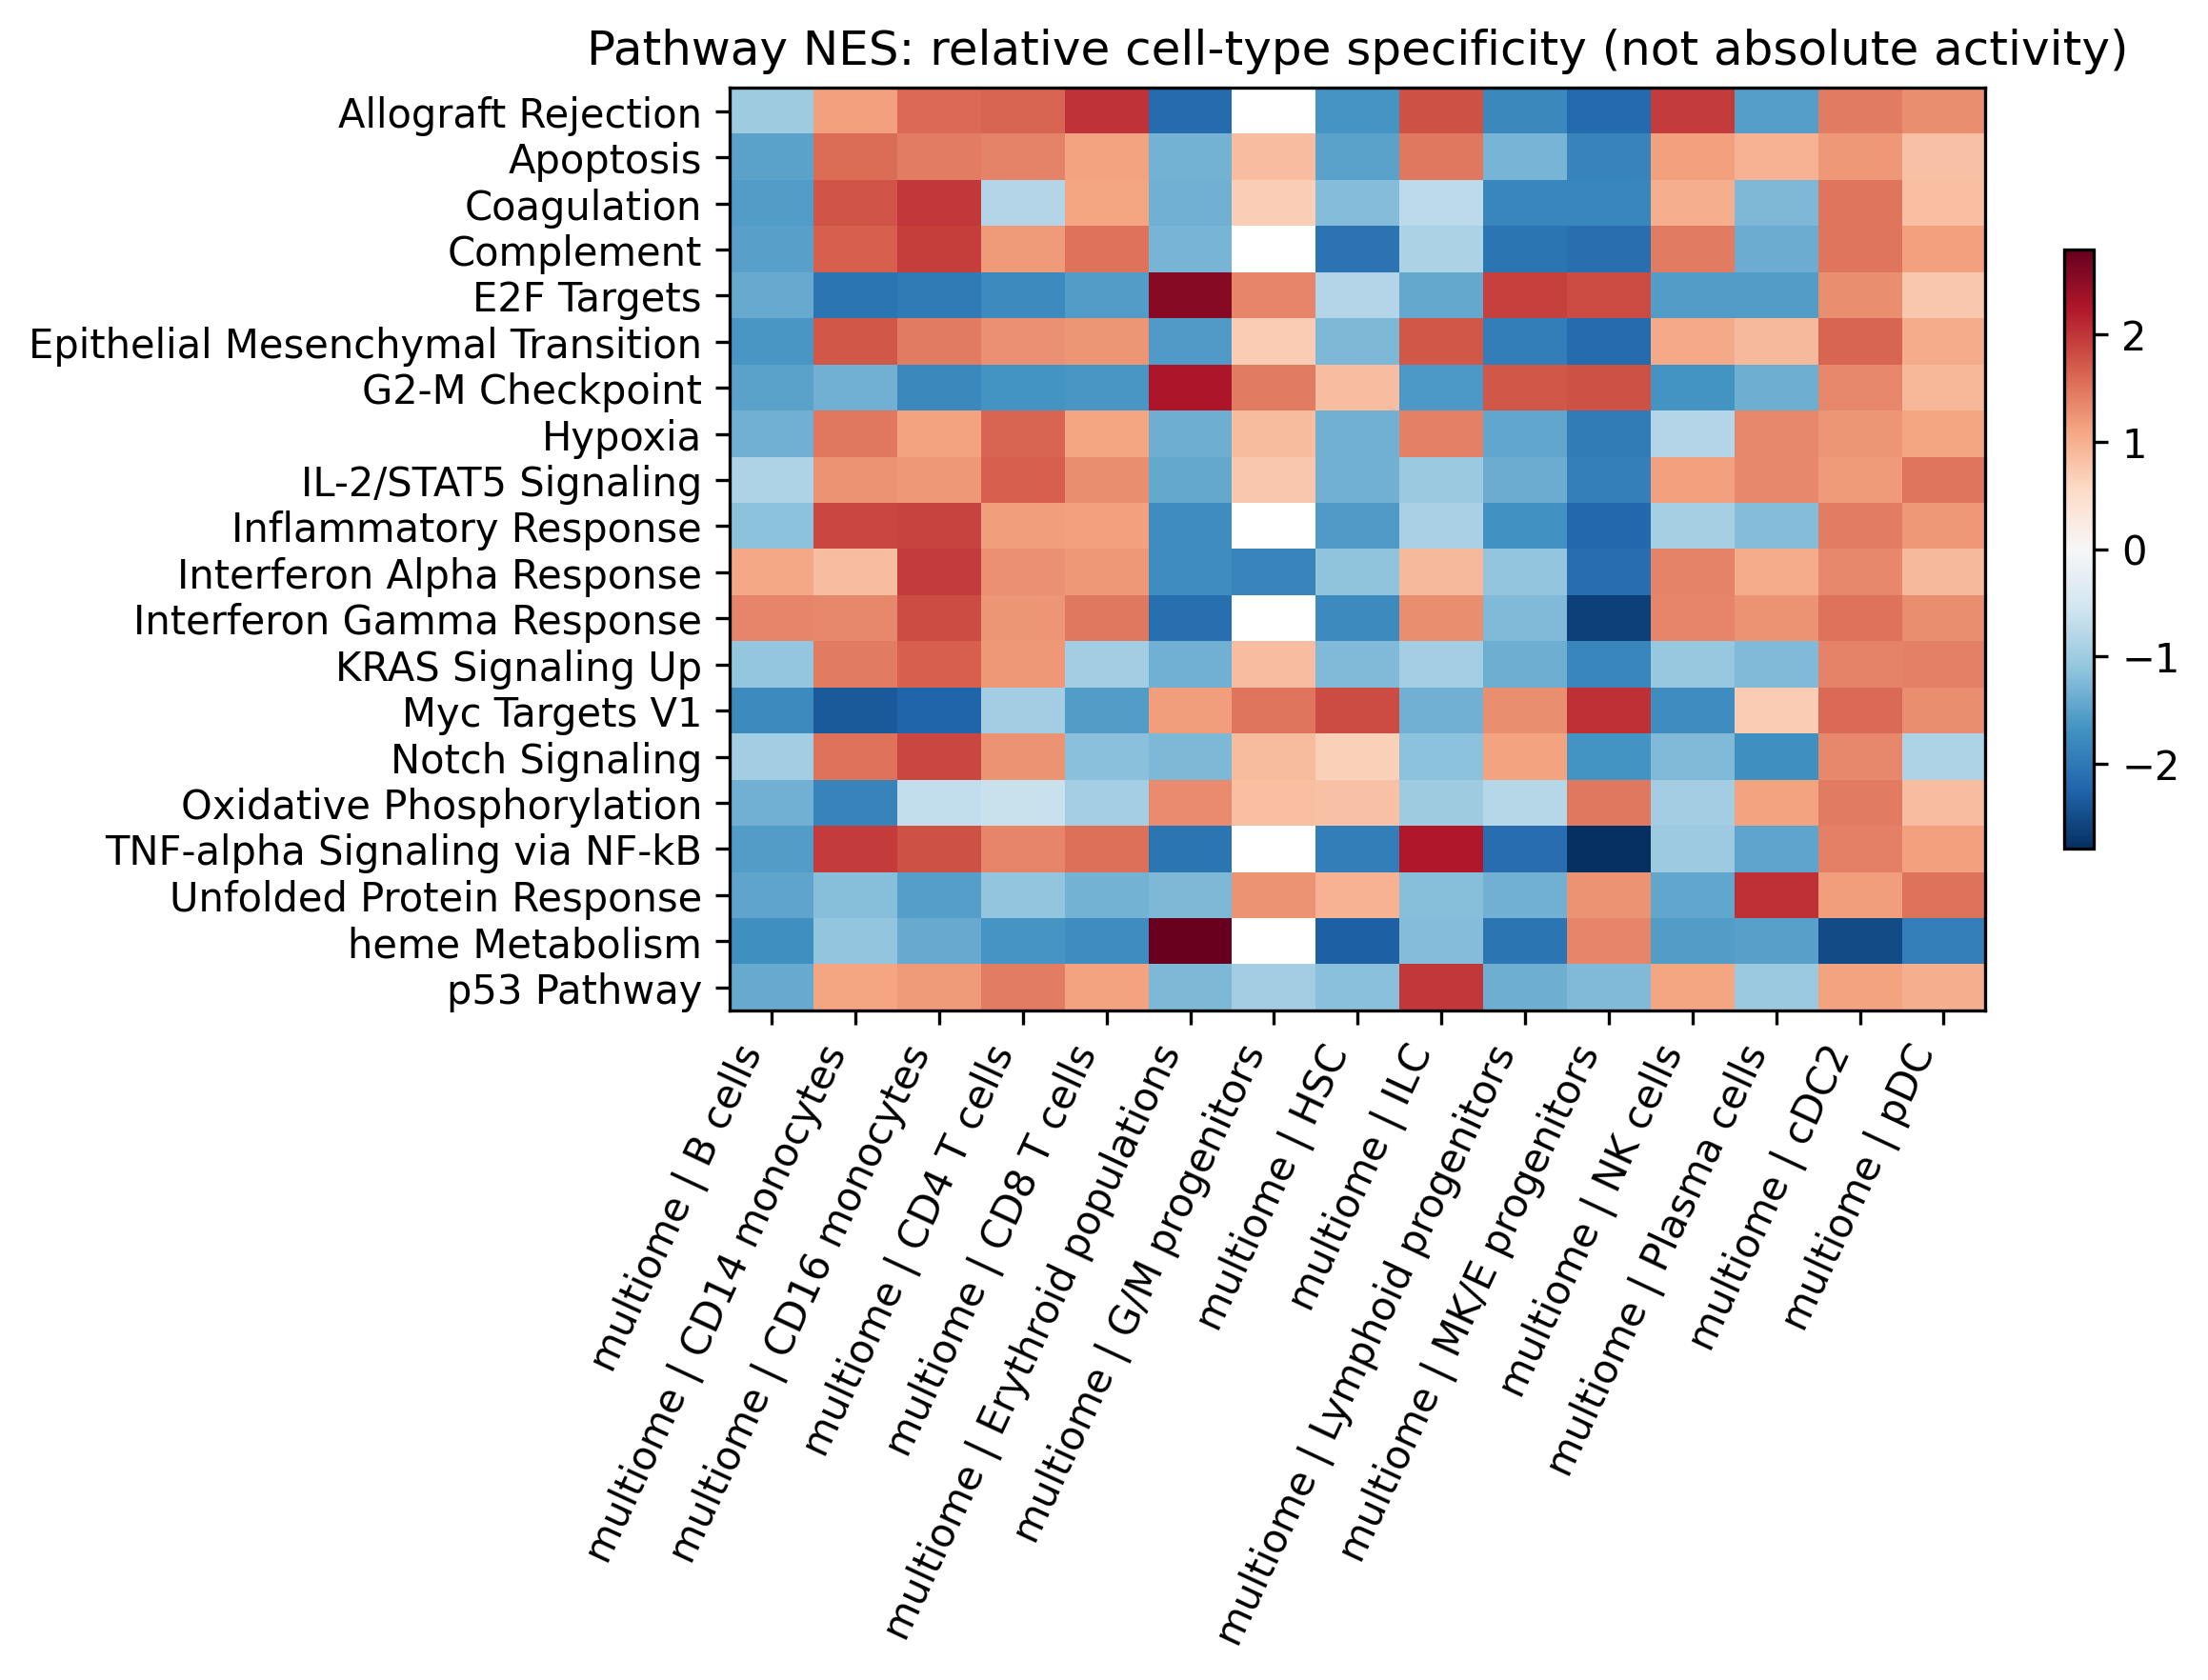

In [4]:
from src.pathway_enrichment import cache_hallmark
from src.single_donor_workflow import characterize_donor

GMT_PATH = DIRS['gsea'] / 'MSigDB_Hallmark_2020.gmt'
# For a custom GMT, replace GMT_PATH and omit cache_hallmark below.
print('Cached collection SHA256:', cache_hallmark(GMT_PATH))
programs, enrichment, universe = characterize_donor(
    rna_data, OUTPUT_ROOT, GMT_PATH, permutations=PERMUTATIONS,
    seed=RANDOM_SEED, detection=MIN_DETECTION, median=COMPUTE_MEDIANS)
print('Shared eligible genes:', len(universe))
display(pd.read_csv(DIRS['gsea'] / 'gene_set_coverage.csv'))
for dataset in ['cite', 'multiome']:
    print(dataset)
    display(programs[dataset].sort_values('specificity', ascending=False).groupby('cell_type').head(5))
    display(enrichment[dataset].sort_values(['cell_type', 'q_value']).groupby('cell_type').head(5))
    display(Image(filename=str(DIRS[f'rna_{dataset}'] / 'figures/characteristic_genes.png')))
    figure = DIRS[f'rna_{dataset}'] / 'figures/pathway_enrichment.png'
    if not enrichment[dataset].empty and figure.exists():
        display(Image(filename=str(figure)))

## Main findings
The next cell reports observed counts and test coverage only. Inspect the saved
rankings and leading-edge genes before writing a biological interpretation. No
biological finding is pre-filled in this unexecuted notebook.

In [5]:
print(f'Donor {donor}: {int(cell_counts.included.sum())} retained shared populations; {len(universe)} comparison genes.')
for dataset, result in enrichment.items():
    print(dataset, ':', len(result), 'pathway/type tests;', int((result.q_value <= 0.05).sum()),
          'with within-ranking BH q <= 0.05 (exploratory).')
print('Next: run nb05 to test concordance and sampling/site sensitivity before any multimodal follow-up.')

Donor 15078: 15 retained shared populations; 12000 comparison genes.
cite : 735 pathway/type tests; 165 with within-ranking BH q <= 0.05 (exploratory).
multiome : 735 pathway/type tests; 126 with within-ranking BH q <= 0.05 (exploratory).
Next: run nb05 to test concordance and sampling/site sensitivity before any multimodal follow-up.


## Limitations
- One healthy donor: no disease/control contrast and no inference across individuals.
- Separate captures: broad cell types may contain different state/subtype mixtures.
- Unequal capture sizes are reported; nb05 performs independent balanced subsampling.
- Site composition may confound pooled donor summaries; nb05 checks shared sites.
- Library normalization uses slightly different measured GEX panels; equal processing
  cannot remove capture, depth, ambient RNA or annotation differences.
- This workflow uses organizer-processed cells with no new QC threshold imposed;
  examine nb01's QC findings and depth summaries before interpretation.
- Gene-set p-values are competitive, exploratory statistics, not donor-level tests.
- Later ADT evidence will cover a limited panel; unmeasured proteins are not negatives.
- Later ATAC gene activity is an approximation, and cross-sectional data cannot prove
  ATAC → RNA → protein causality or temporal priming.